## Imports

In [84]:
import numpy as np

import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch_geometric.utils import to_networkx

import matplotlib.pyplot as plt
import networkx as nx
import os

from datetime import datetime

## LOADING THE DATA

In [85]:
dataset = torch.load('../data/final_dataset/graph/graphs_sequential_new.pt', weights_only=False)

In [86]:
# Split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15
total = len(dataset)

batch_size = 1 

train_dataset = dataset[:int(total * train_ratio)]
val_dataset   = dataset[int(total * train_ratio):int(total * (train_ratio + val_ratio))]
test_dataset  = dataset[int(total * (train_ratio + val_ratio)):]

# Create loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

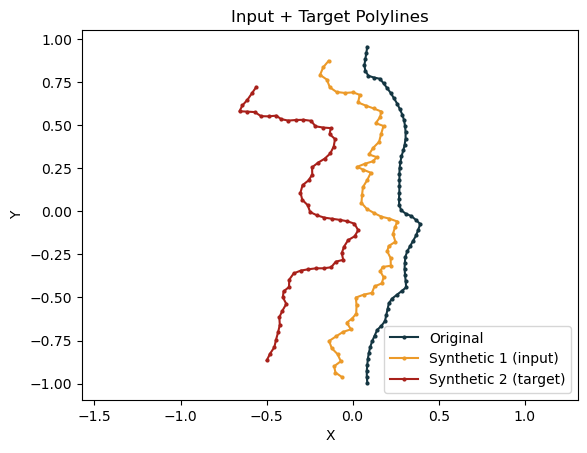

In [87]:
def plot_graph_with_targets(data):

    num_nodes = data.num_nodes
    seq_len = num_nodes // 2  # assuming only original + synthetic_1

    # Extract node positions
    coords = data.x[:,1:3].detach().numpy()       # (num_nodes,2)
    shifts = data.y[:,0:2].detach().numpy()      # (num_nodes,2)

    # Separate lines
    orig_coords = coords[data.x[:,0]==0]
    syn1_coords = coords[data.x[:,0]==1]
    syn1_targets = syn1_coords + shifts[data.x[:,0]==1]  # synthetic_2

    # Plot original
    plt.plot(orig_coords[:,0], orig_coords[:,1], '-o', label='Original', markersize=2, color="#143642")

    # Plot synthetic_1 (input)
    plt.plot(syn1_coords[:,0], syn1_coords[:,1], '-o', label='Synthetic 1 (input)', markersize=2, color="#EC9A29")

    # Plot synthetic_2 (target)
    plt.plot(syn1_targets[:,0], syn1_targets[:,1], '-o', label='Synthetic 2 (target)', markersize=2, color="#A8201A")

    # Optionally draw arrows to show shifts
    for i in range(seq_len):
        plt.arrow(syn1_coords[i,0], syn1_coords[i,1],
                  shifts[i,0], shifts[i,1],
                  head_width=0.002, head_length=0.004, fc='gray', ec='gray', alpha=0.5)

    plt.title("Input + Target Polylines")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.axis('equal')
    plt.legend()
    plt.show()


# ---- Example usage ----
first_item = test_dataset[2]
plot_graph_with_targets(first_item)


In [ ]:
# # get one batch
# batch = next(iter(test_loader))

# # if batch_size=1 → direct
# if hasattr(batch, 'num_graphs') and batch.num_graphs == 1:
#     plot_graph(batch)

# # if batch_size>1 → extract the first graph inside the batch
# else:
#     from torch_geometric.data import Batch
#     # Unbatch the graphs
#     graphs = batch.to_data_list()
#     print(f"Batch contains {len(graphs)} graphs")

#     # plot first graph
#     plot_graph(graphs[0])


## TRAINING THE MODEL

In [92]:
#device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Extract feature dimensions and number of classes
sample = dataset[0]
in_channels = sample.num_features  # stays the same
out_channels = sample.y.shape[1]   # should be 2 (Δx, Δy)
print("In Channels:", in_channels)
print("Out Channels:", out_channels)

#
hidden_channels = 32  # GAT hidden dim
heads = 4
lr = 0.001 #0.005


Using device: cpu
In Channels: 5
Out Channels: 2


In [93]:
class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=0.6)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=0.6)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.6, training=self.training)
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv2(x, edge_index)
        return x

In [94]:
def save_checkpoint(epoch, model, optimizer, train_losses, val_losses, path="checkpoint.pt"):
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_losses": train_losses,
        "val_losses": val_losses,
    }
    torch.save(checkpoint, path)
    print(f"Checkpoint saved to {path}")


In [95]:
def load_checkpoint(path, model, optimizer=None):
    checkpoint = torch.load(path, map_location="cpu")
    
    model.load_state_dict(checkpoint["model_state_dict"])
    
    if optimizer is not None:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    
    train_losses = checkpoint.get("train_losses", [])
    val_losses = checkpoint.get("val_losses", [])
    start_epoch = checkpoint["epoch"] + 1

    print(f"Loaded checkpoint from epoch {checkpoint['epoch']}")
    
    return start_epoch, train_losses, val_losses

In [96]:
model = GAT(in_channels, hidden_channels, out_channels, heads).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
criterion = torch.nn.MSELoss()

def train_epoch(loader):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index)
        
        mask = batch.x[:,0] == 1       # only synthetic_1 nodes
        loss = criterion(out[mask], batch.y[mask])
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def evaluate(loader):
    model.eval()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index)
        mask = batch.x[:,0] == 1       # only synthetic_1 nodes
        loss = criterion(out[mask], batch.y[mask])
        total_loss += loss.item()
    return total_loss / len(loader)


### TRAINING LOOP

In [97]:
epochs = 50
train_losses, val_losses = [], []
best_val_loss = float("inf")
timestamp = datetime.now().strftime('%d%m_%H%M')

# Reload and resume training
#start_epoch, train_losses, val_losses = load_checkpoint("checkpoint.pt", model, optimizer)

for epoch in range(epochs): #1, epochs + 1
    train_loss = train_epoch(train_loader)
    val_loss = evaluate(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    # Save every epoch:
    #save_checkpoint(epoch, model, optimizer, train_losses, val_losses, "checkpoint.pt")

    # Or only save when validation improves:
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_checkpoint(epoch, model, optimizer, train_losses, val_losses, f'../checkpoints/graph/model/{batch_size}_batches_{epochs}_epochs_{timestamp}.pt')

Epoch 001 | Train Loss: 0.010287 | Val Loss: 0.010241
Checkpoint saved to ../checkpoints/graph/1_batches_50_epochs_2811_1705.pt
Epoch 002 | Train Loss: 0.008786 | Val Loss: 0.009991
Checkpoint saved to ../checkpoints/graph/1_batches_50_epochs_2811_1705.pt
Epoch 003 | Train Loss: 0.008802 | Val Loss: 0.010730
Epoch 004 | Train Loss: 0.008795 | Val Loss: 0.010062
Epoch 005 | Train Loss: 0.008807 | Val Loss: 0.010697
Epoch 006 | Train Loss: 0.008853 | Val Loss: 0.010185
Epoch 007 | Train Loss: 0.008824 | Val Loss: 0.009954
Checkpoint saved to ../checkpoints/graph/1_batches_50_epochs_2811_1705.pt
Epoch 008 | Train Loss: 0.008790 | Val Loss: 0.010123
Epoch 009 | Train Loss: 0.008779 | Val Loss: 0.010069
Epoch 010 | Train Loss: 0.008834 | Val Loss: 0.010146
Epoch 011 | Train Loss: 0.008832 | Val Loss: 0.009857
Checkpoint saved to ../checkpoints/graph/1_batches_50_epochs_2811_1705.pt
Epoch 012 | Train Loss: 0.008812 | Val Loss: 0.010295
Epoch 013 | Train Loss: 0.008787 | Val Loss: 0.009971
Ep

### PLOTTING TRAINING LOSS

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(range(1, epochs+1), train_losses, label='Train Loss') #range(1, epochs+1)
plt.plot(range(1, epochs+1), val_losses, label='Validation Loss') #range(1, epochs+1)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

## POST TRAINING

In [99]:
def plot_prediction(model, data):
    """
    Plot synthetic_2 ground truth vs synthetic_2 predicted
    for one PyG Data object.
    """

    model.eval()
    data = data.to(device)

    # ---- PREDICT SHIFTS ----
    with torch.no_grad():
        pred_shift = model(data.x, data.edge_index)

    # CPU numpy
    coords = data.x[:,1:3].cpu().numpy()
    true_shift = data.y[:,0:2].cpu().numpy()
    pred_shift = pred_shift.cpu().numpy()

    # Separate lines by line_id
    line_id = data.x[:,0].cpu().numpy()

    orig_coords = coords[line_id == 0]
    syn1_coords = coords[line_id == 1]

    true_s2 = syn1_coords + true_shift[line_id == 1]
    pred_s2 = syn1_coords + pred_shift[line_id == 1]

    plt.figure(figsize=(8,7))

    # Original
    plt.plot(orig_coords[:,0], orig_coords[:,1],
             '-o', color="#143642", markersize=2, label="Original")

    # Synthetic-1 (input)
    plt.plot(syn1_coords[:,0], syn1_coords[:,1],
             '-o', color="#EC9A29", markersize=2, label="Synthetic 1 (input)")

    # True Synthetic-2
    plt.plot(true_s2[:,0], true_s2[:,1],
             '-o', color="#A8201A", markersize=2, label="Synthetic 2 (target)")

    # Predicted Synthetic-2
    plt.plot(pred_s2[:,0], pred_s2[:,1],
             '-o', color="#1C7C54", markersize=2, label="Synthetic 2 (predicted)")

    # Optional: draw shift arrows
    for i in range(len(syn1_coords)):
        plt.arrow(
            syn1_coords[i,0], syn1_coords[i,1],
            pred_s2[i,0] - syn1_coords[i,0],
            pred_s2[i,1] - syn1_coords[i,1],
            head_width=0.002, head_length=0.004,
            fc="#1C7C54", ec="#1C7C54", alpha=0.4
        )

    plt.title("Prediction vs Ground Truth")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.axis("equal")
    plt.legend()
    plt.show()


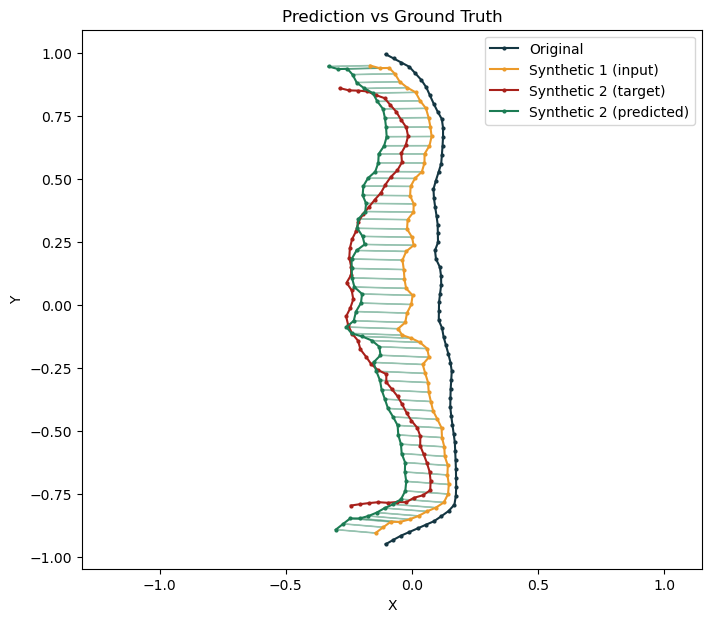

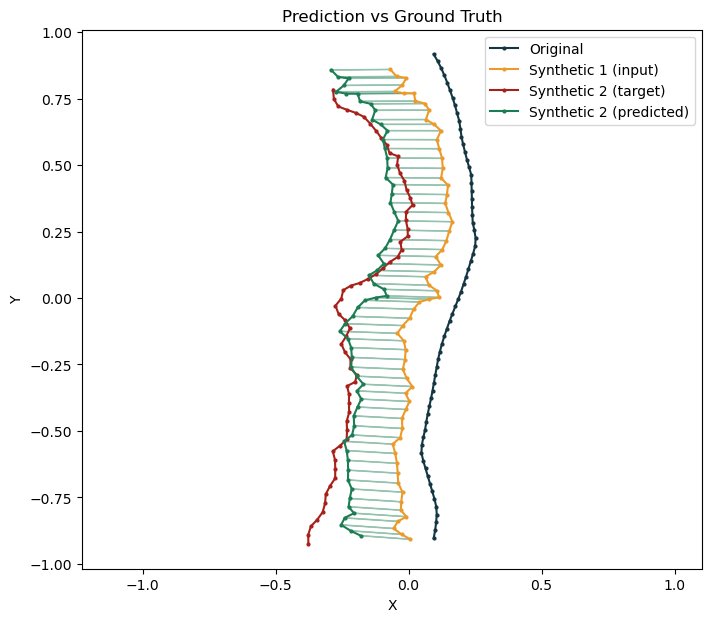

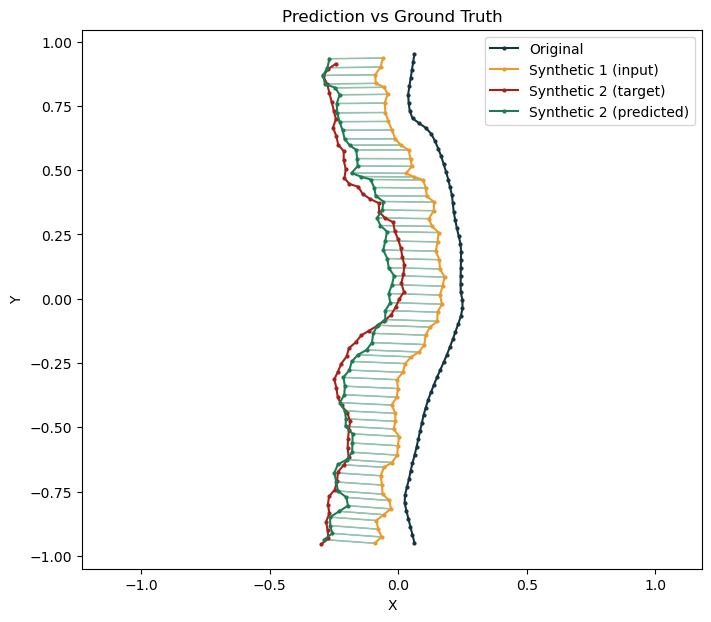

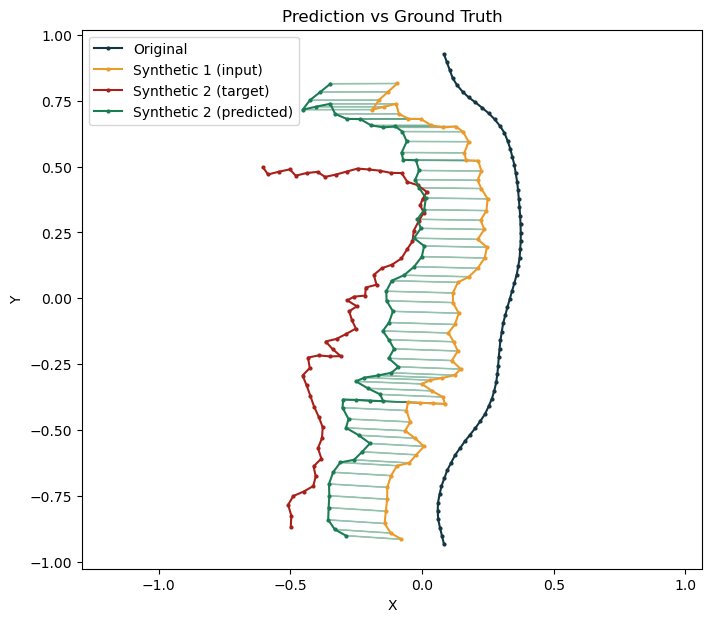

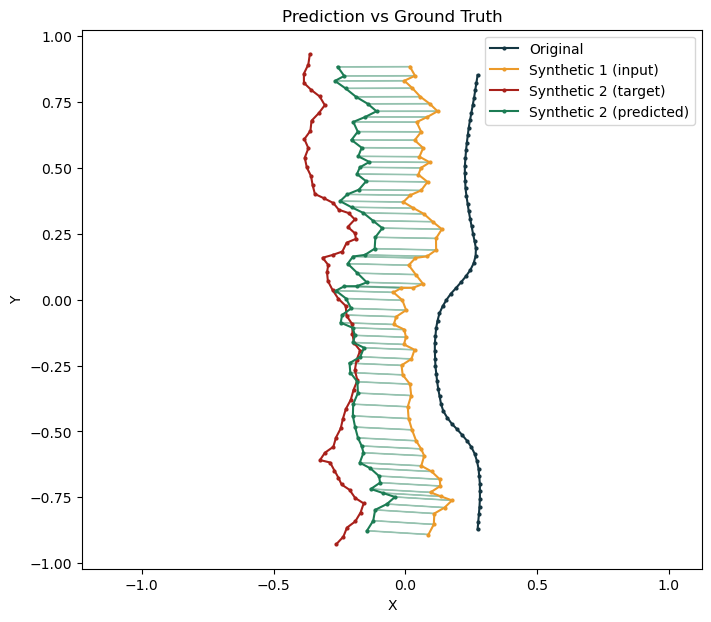

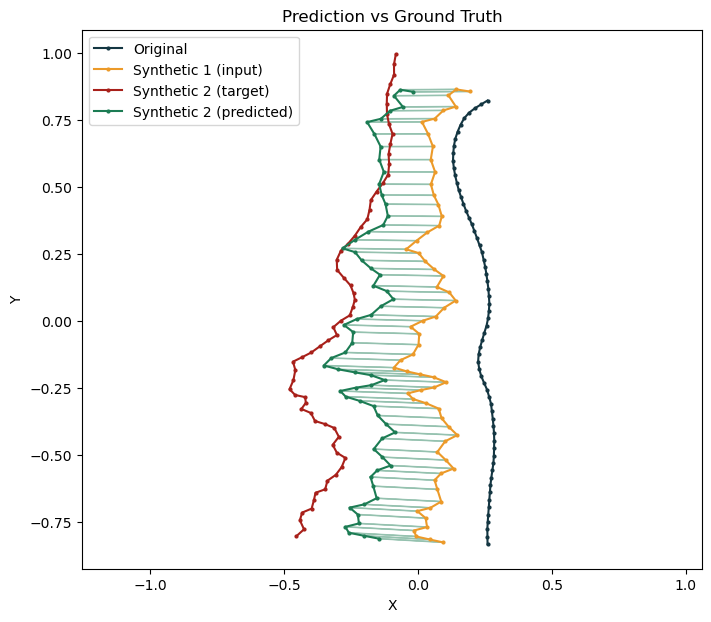

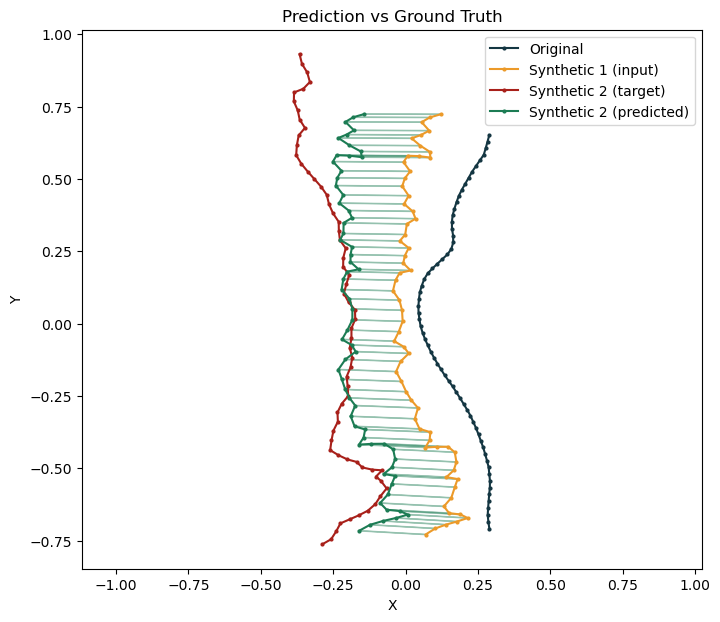

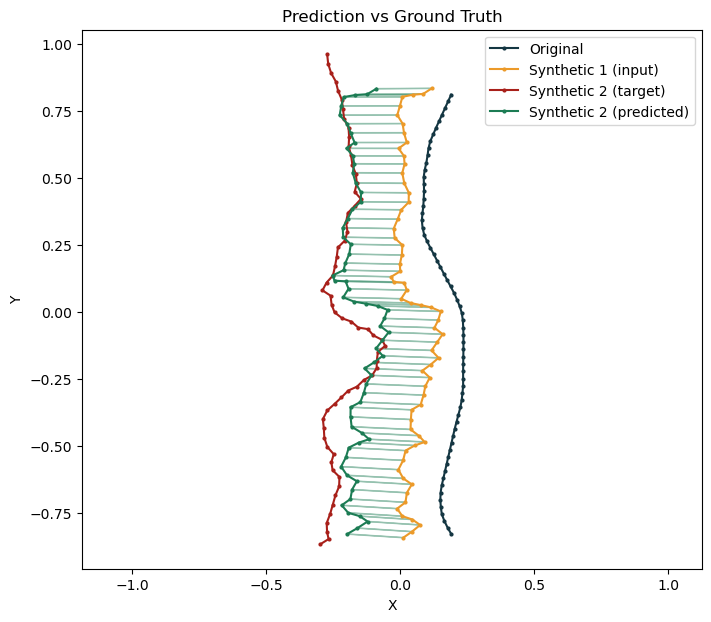

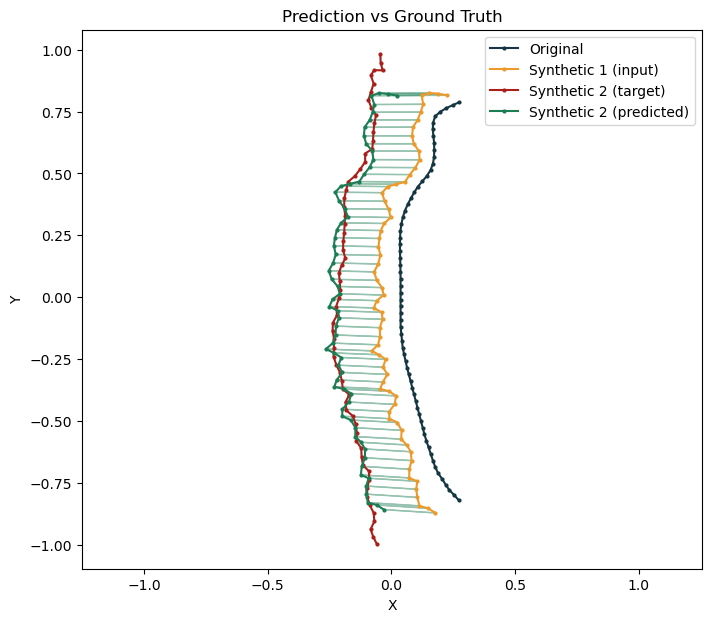

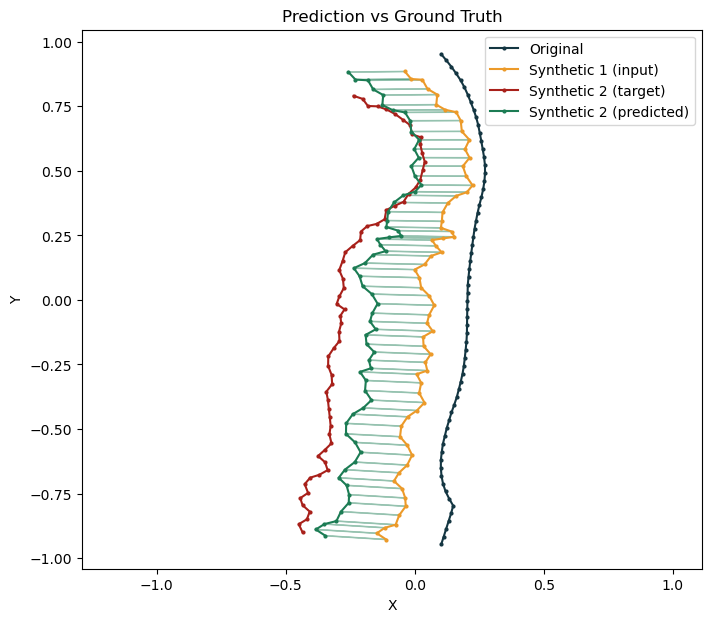

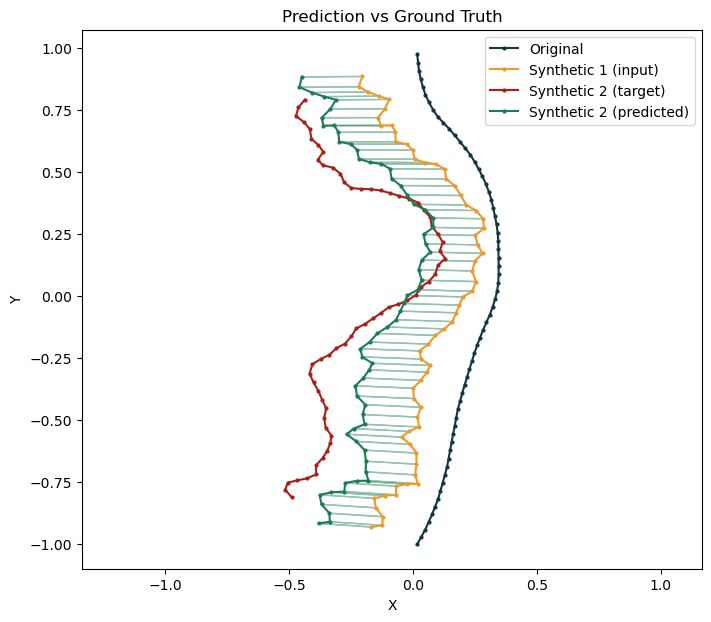

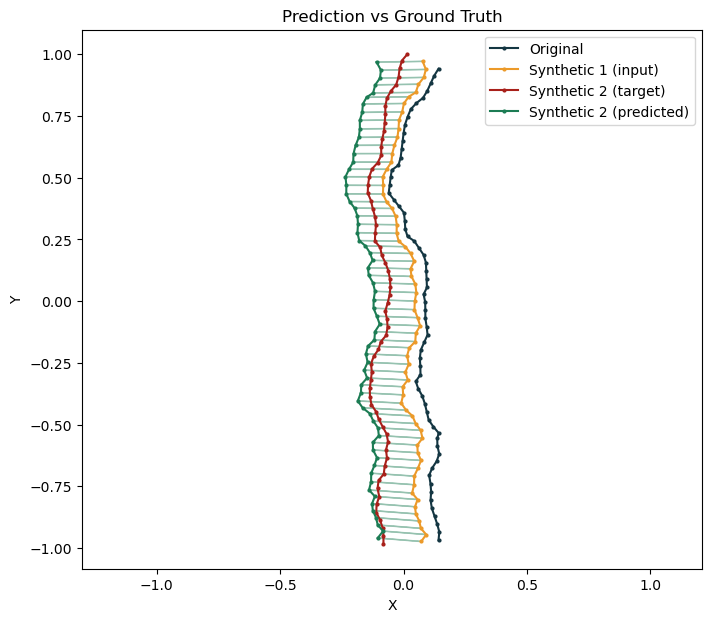

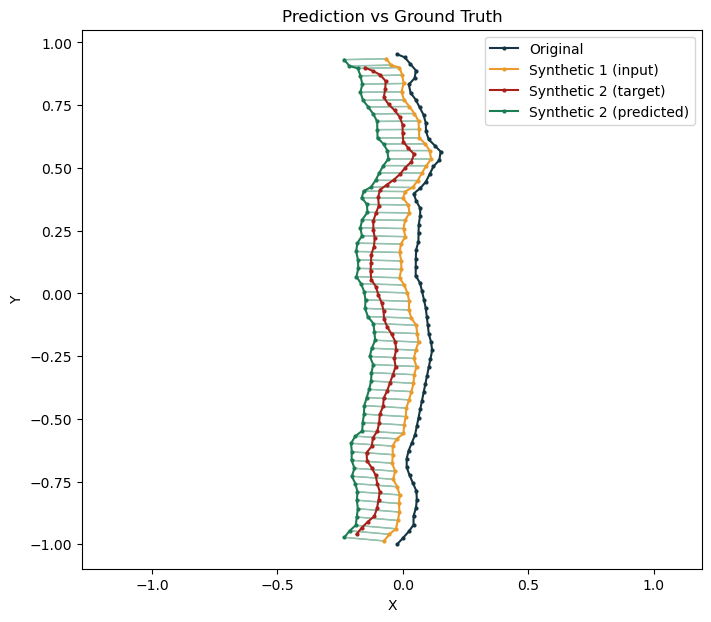

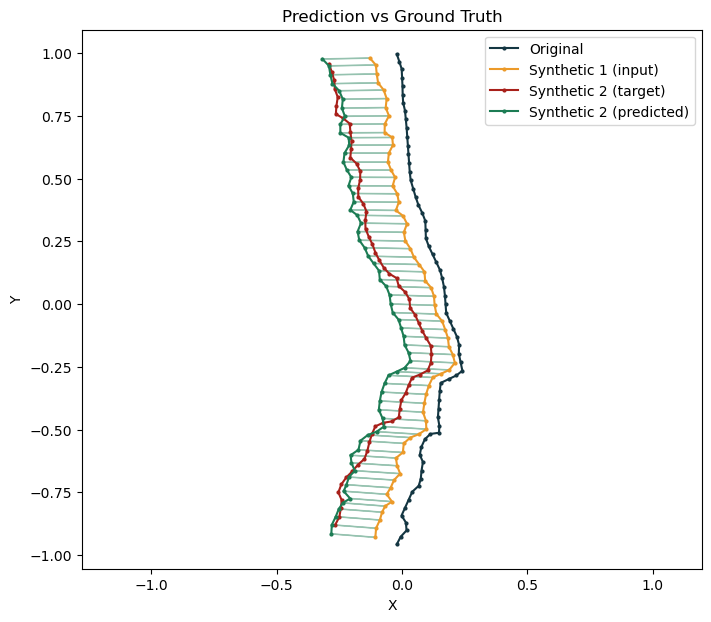

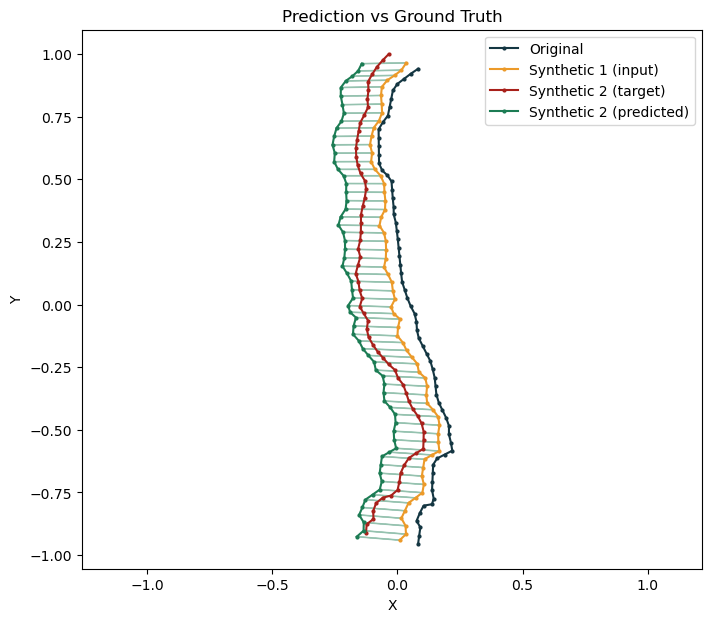

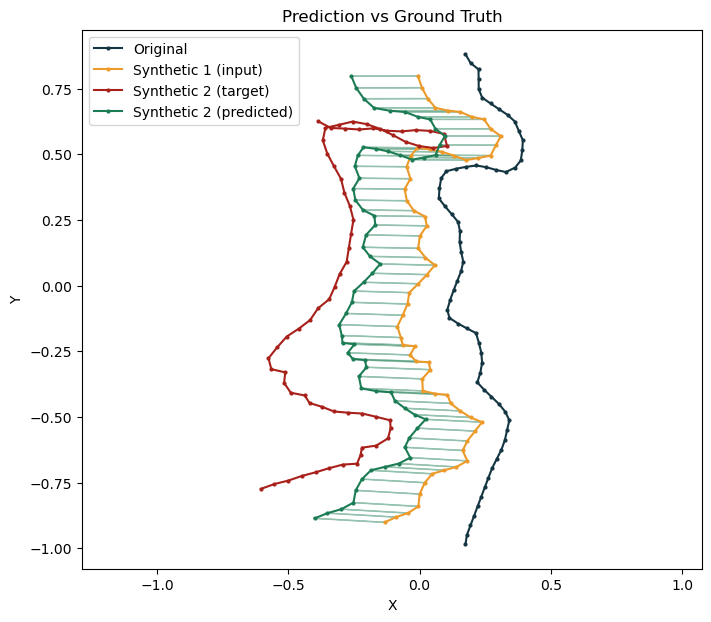

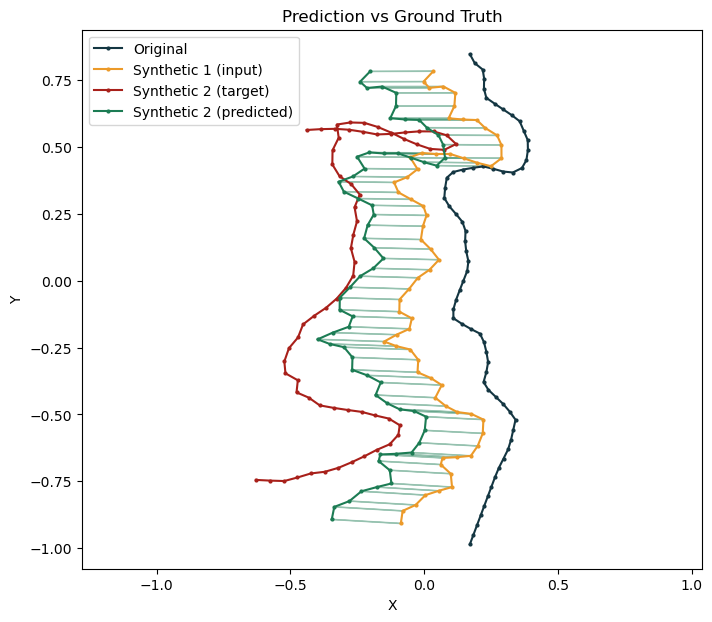

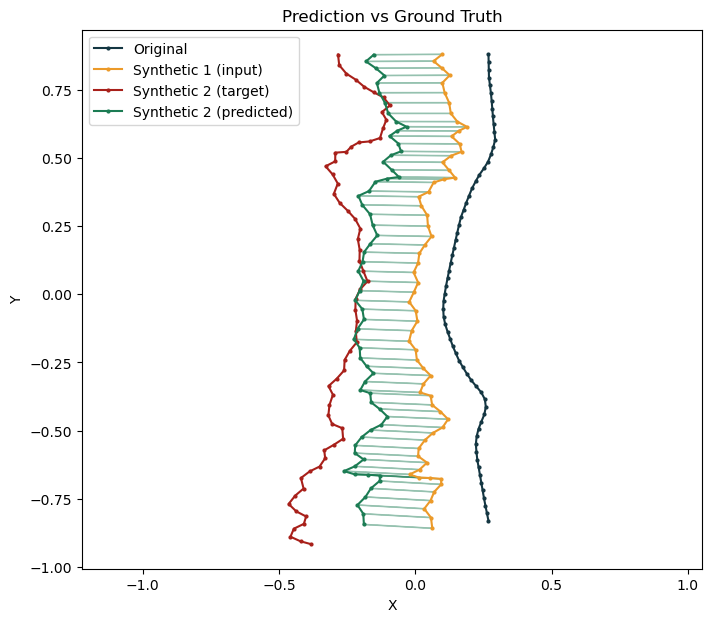

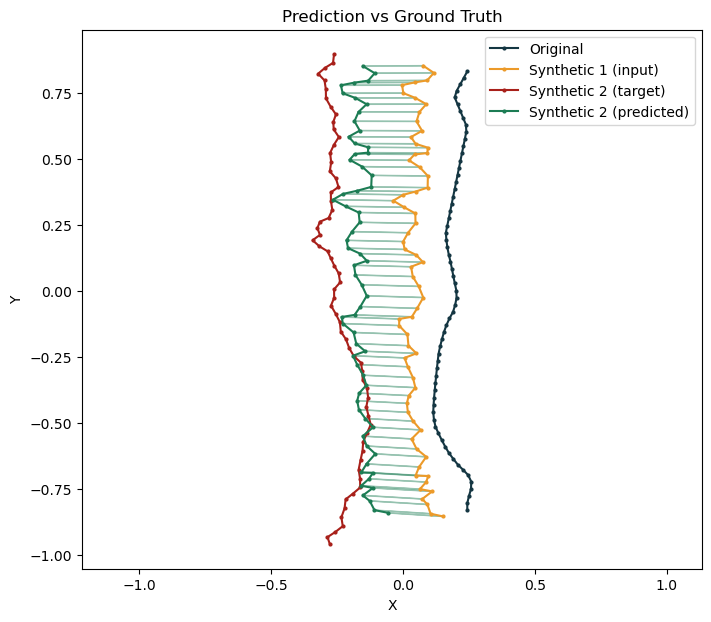

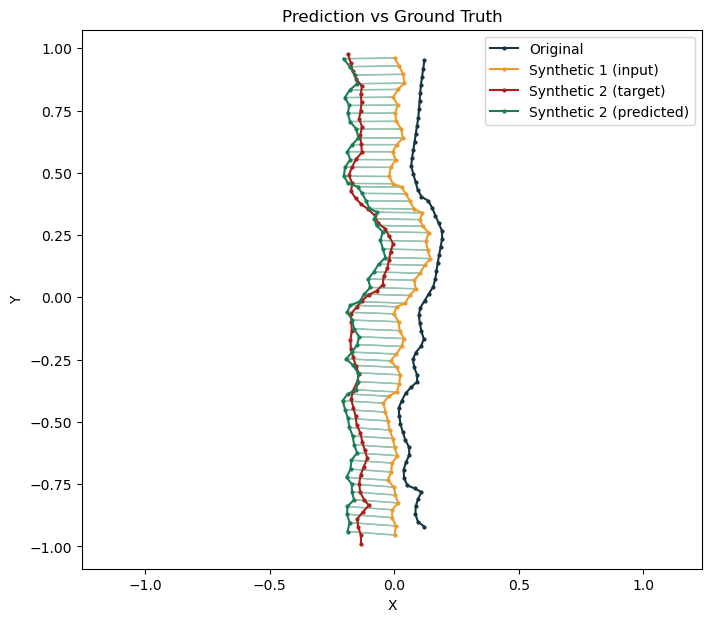

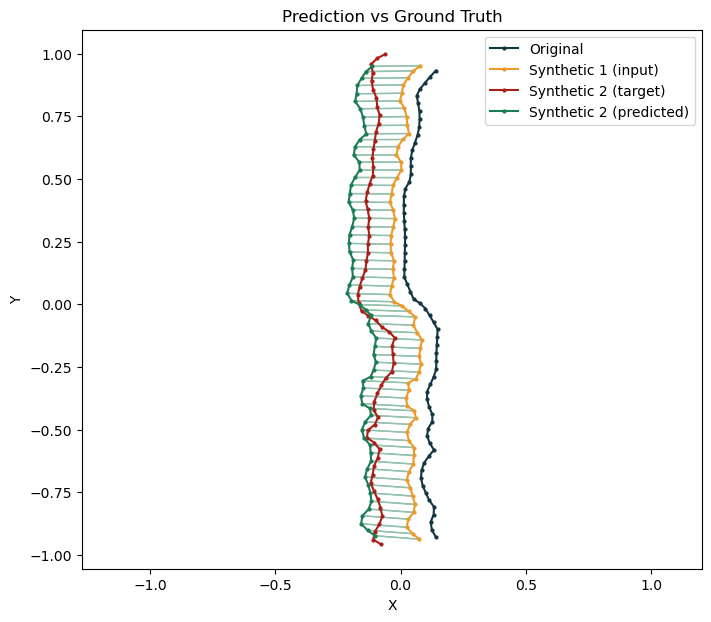

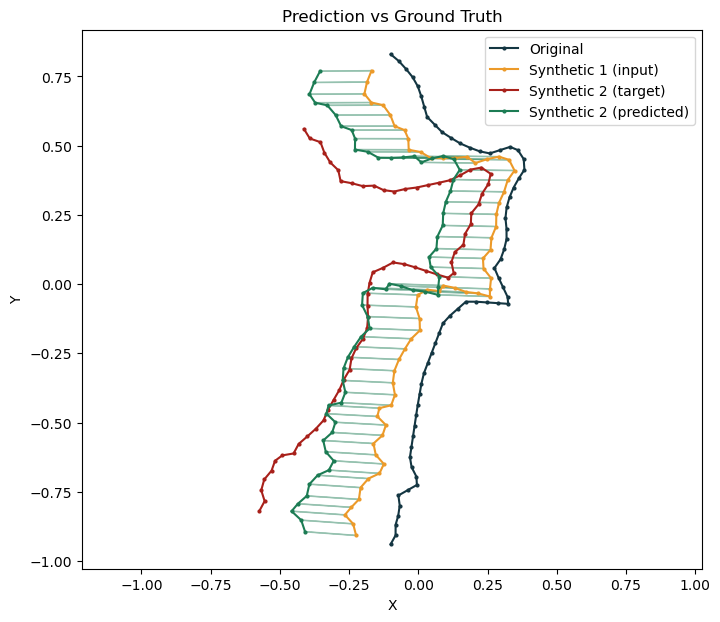

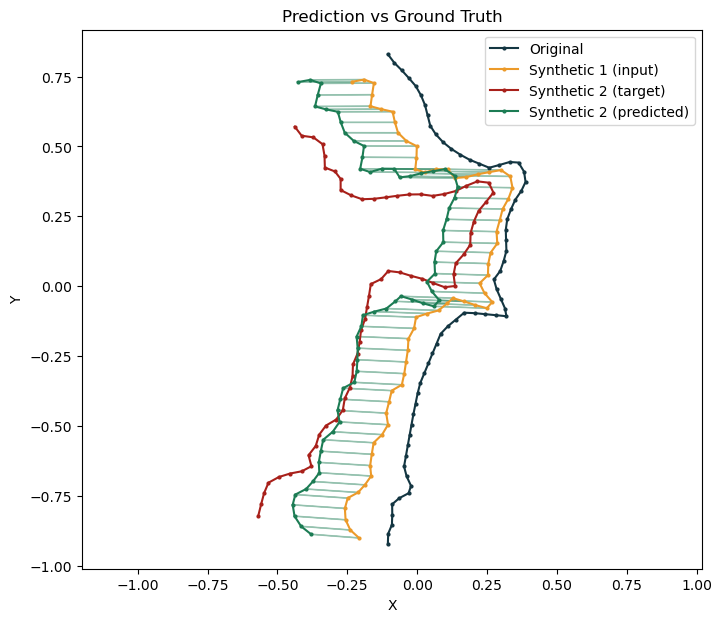

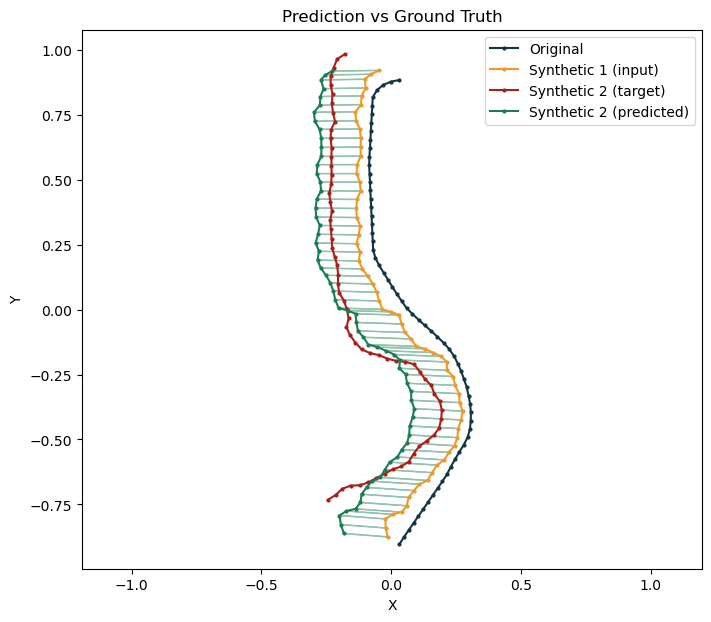

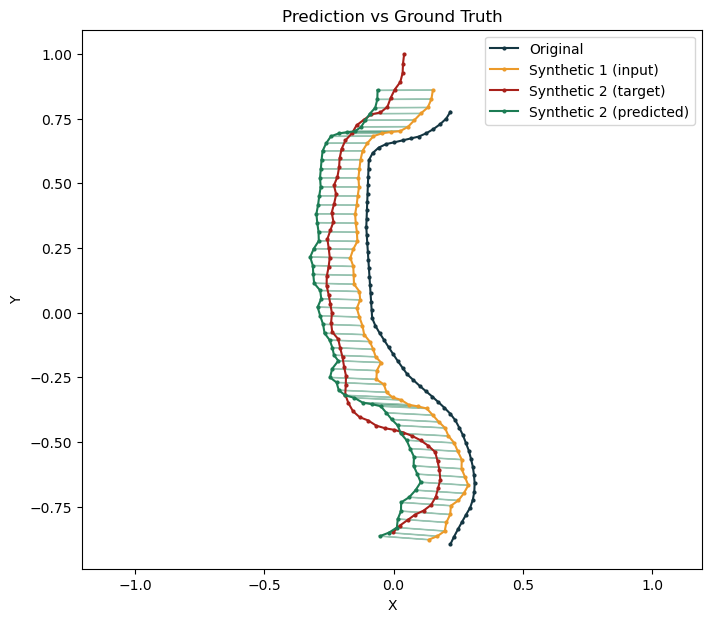

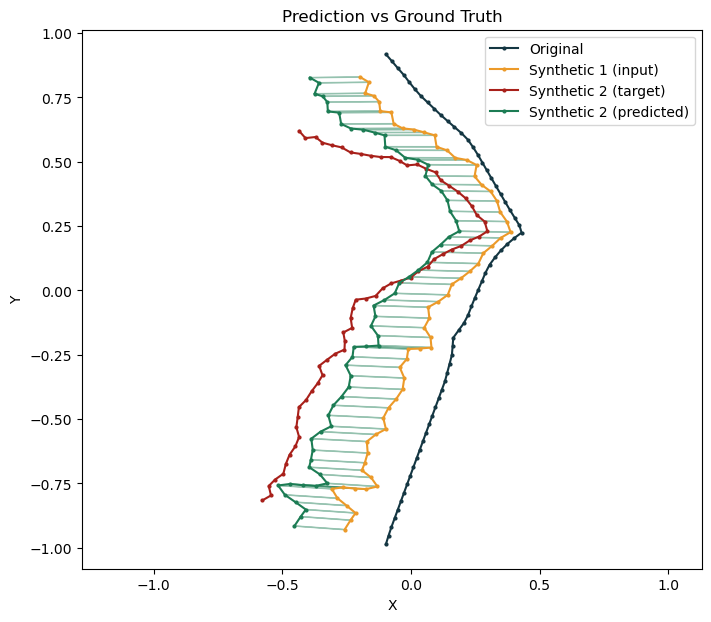

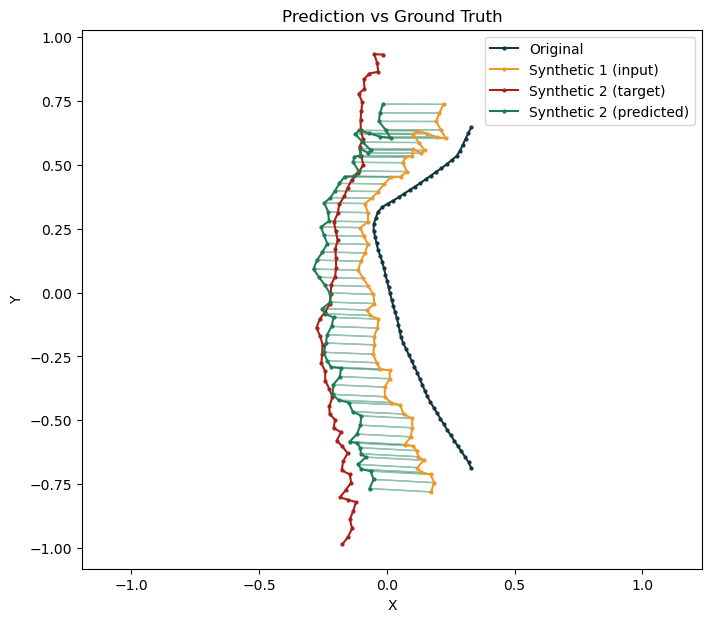

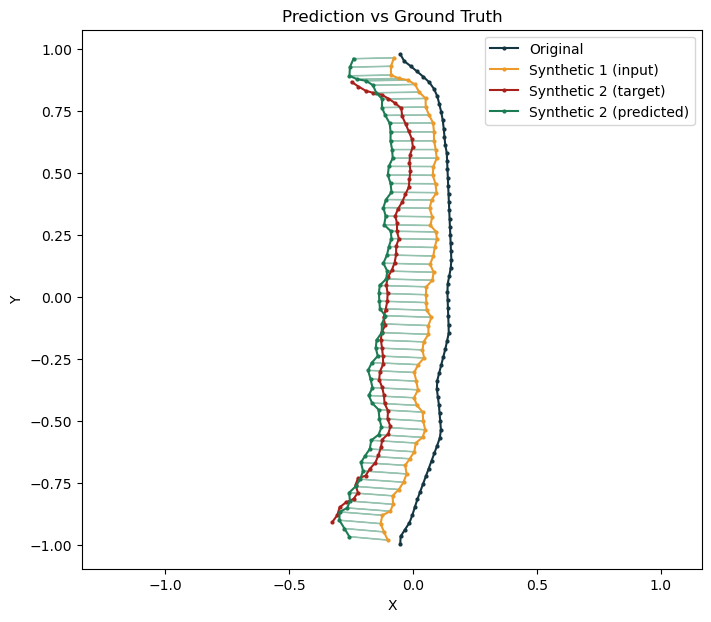

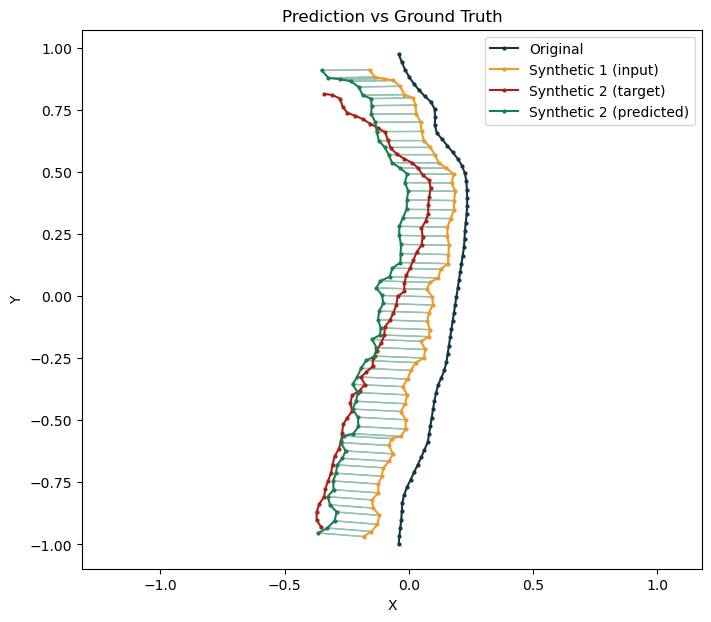

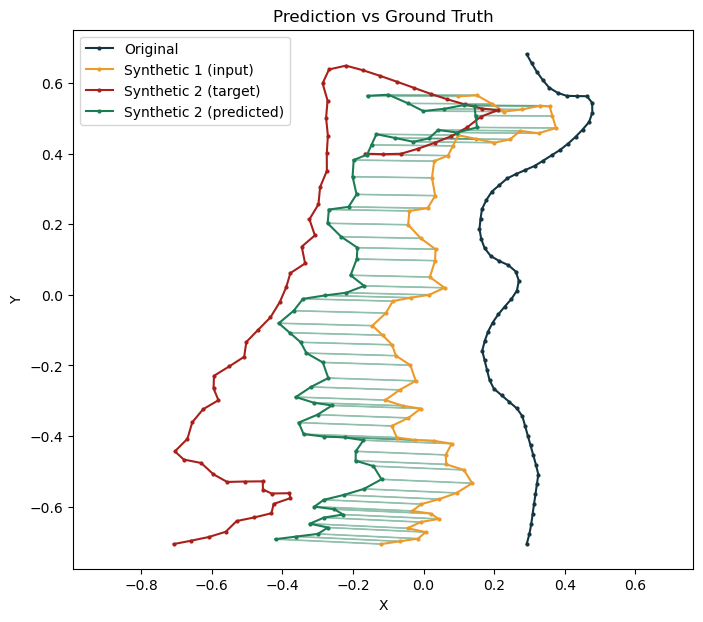

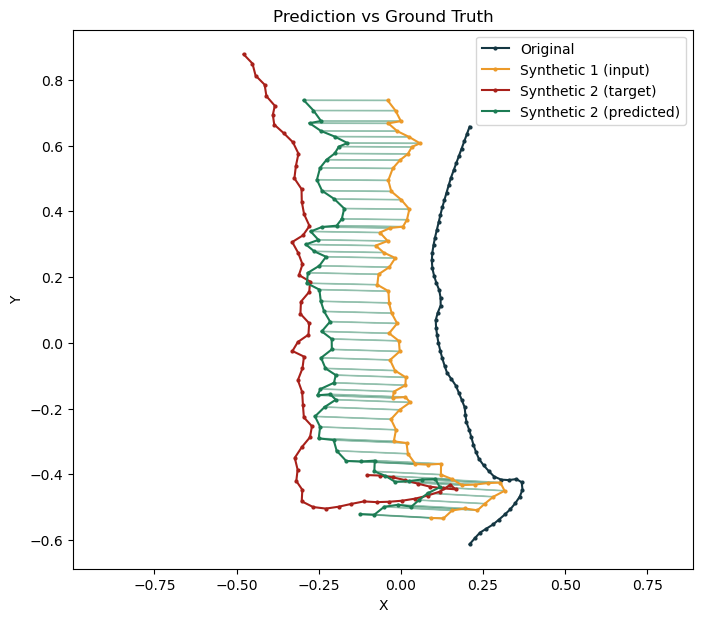

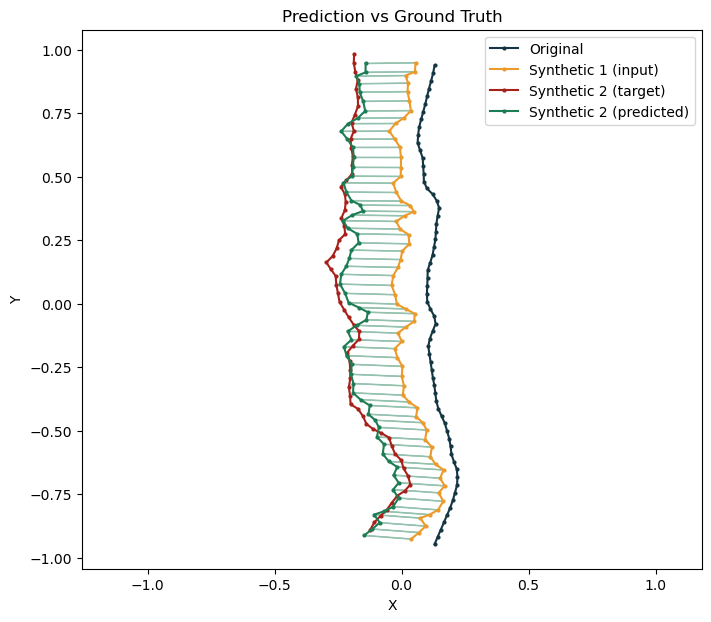

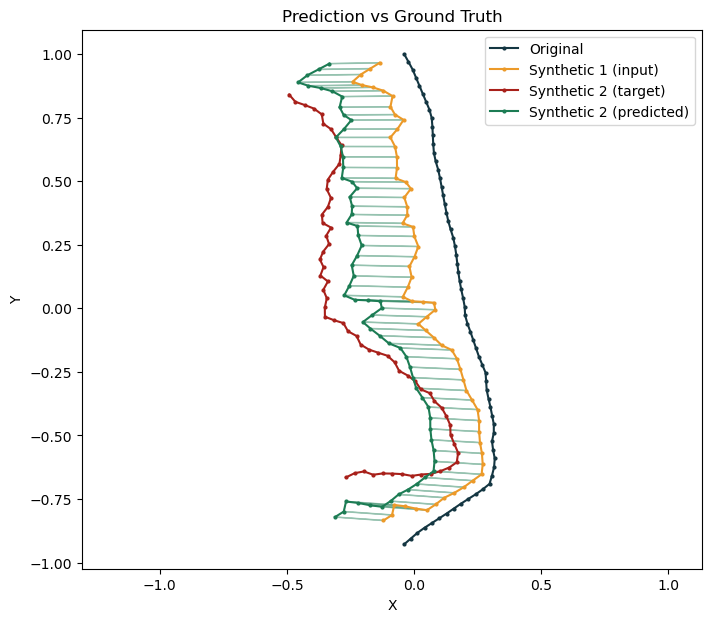

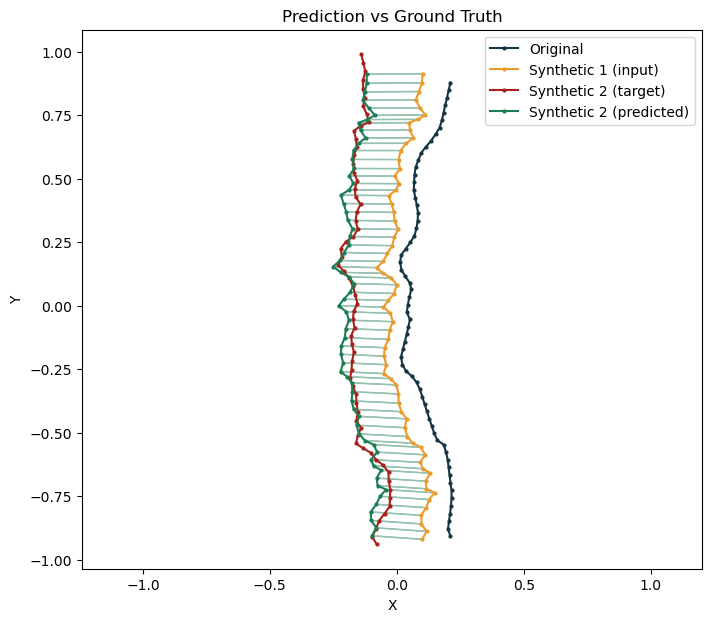

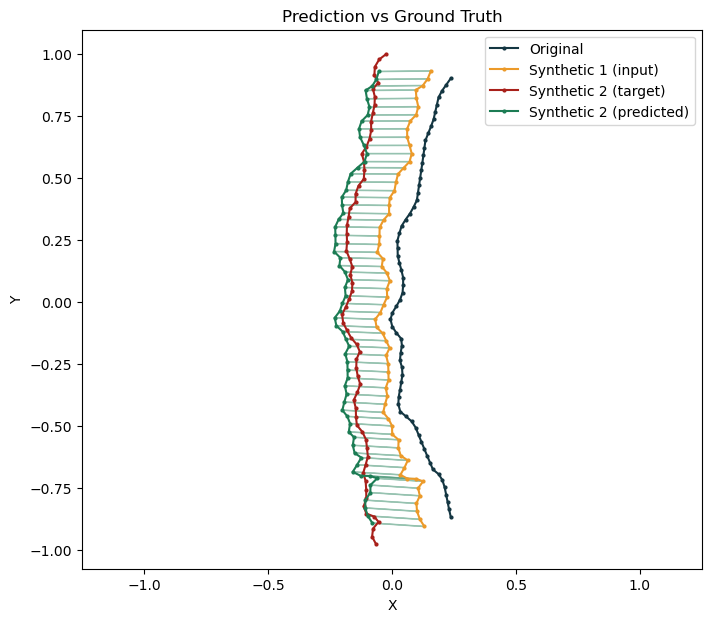

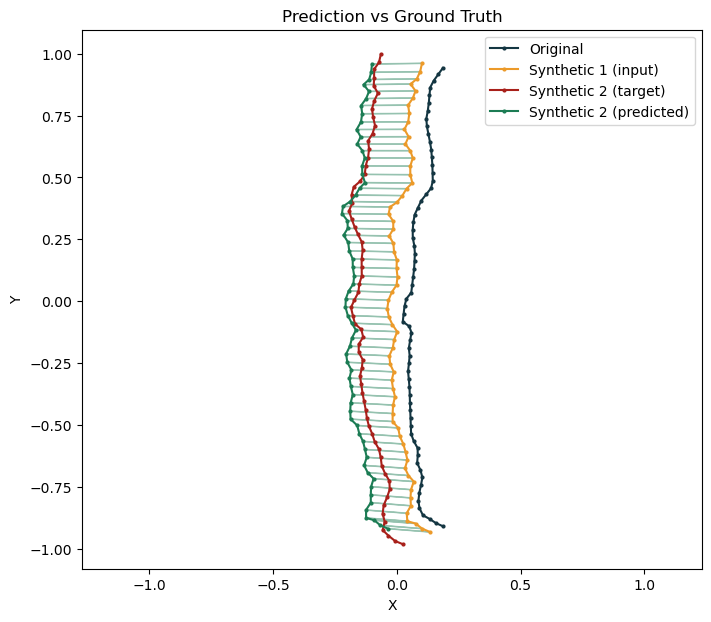

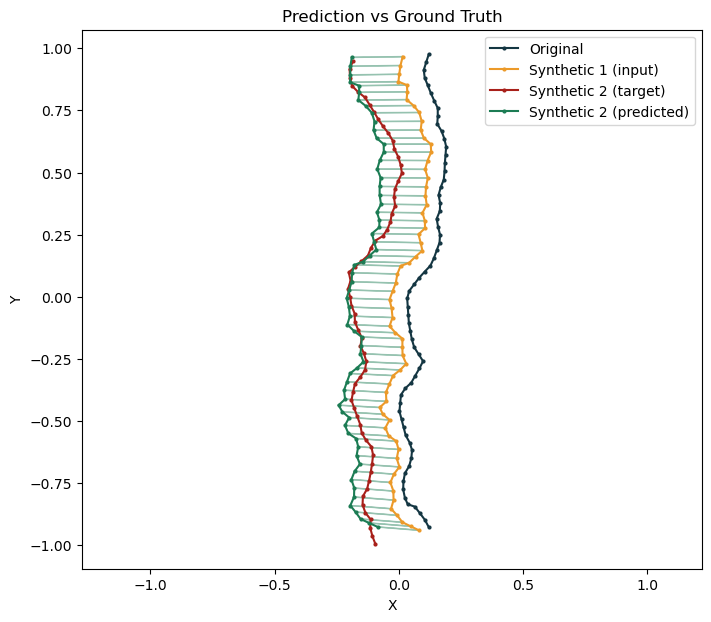

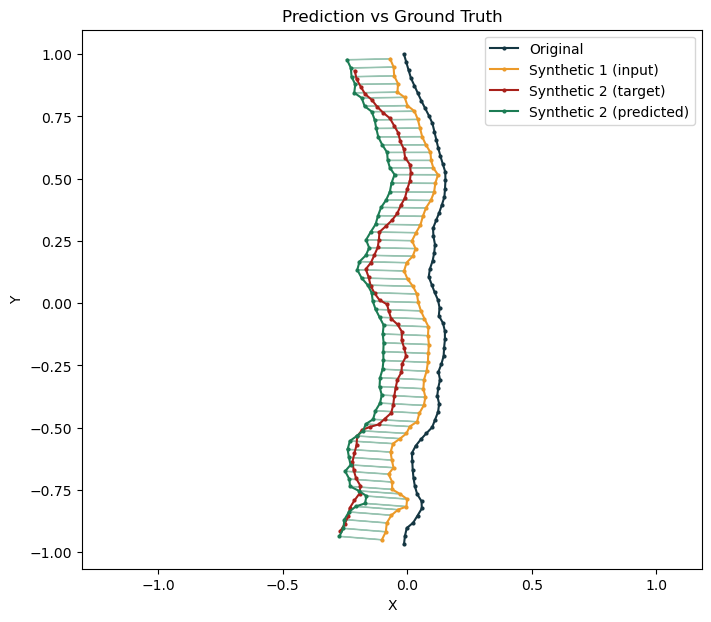

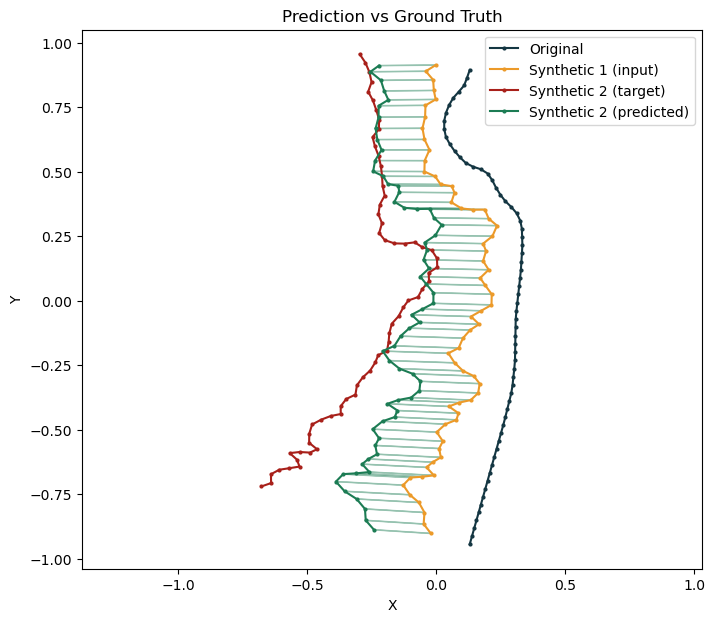

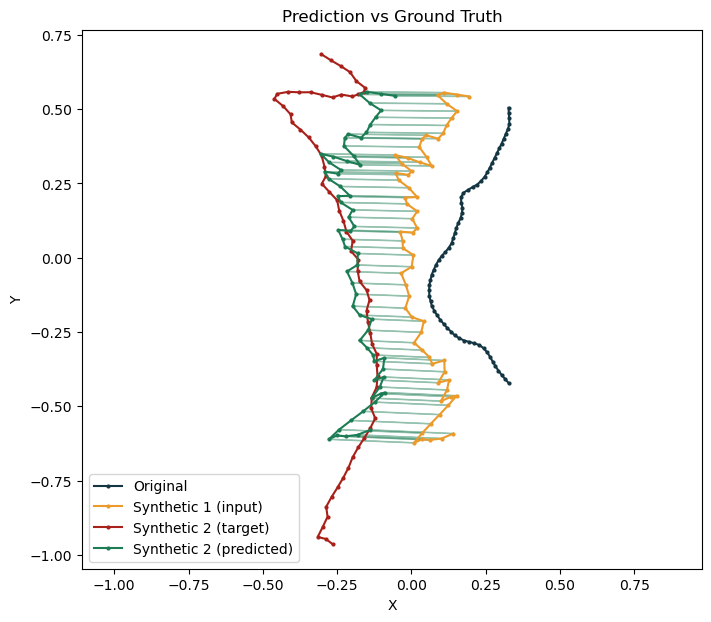

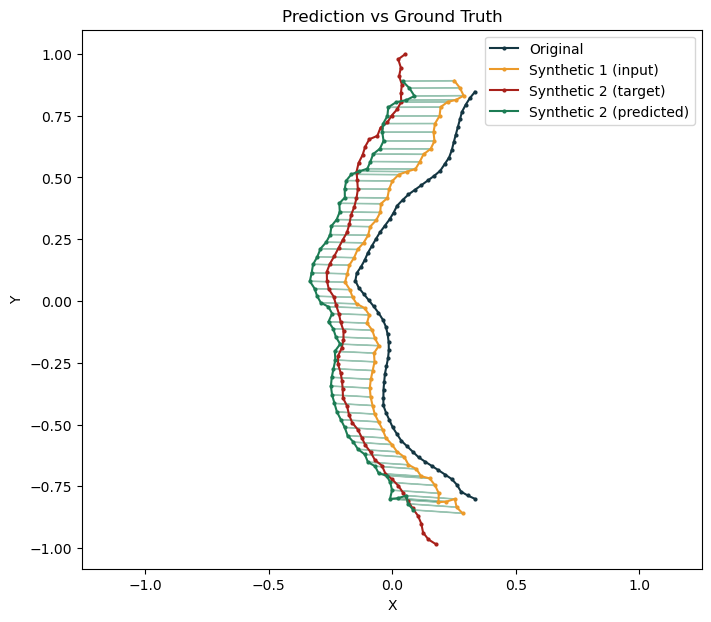

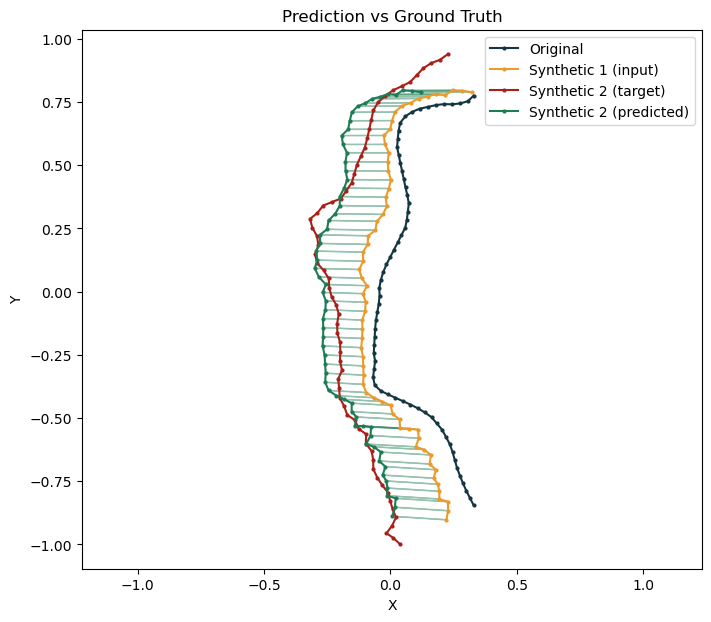

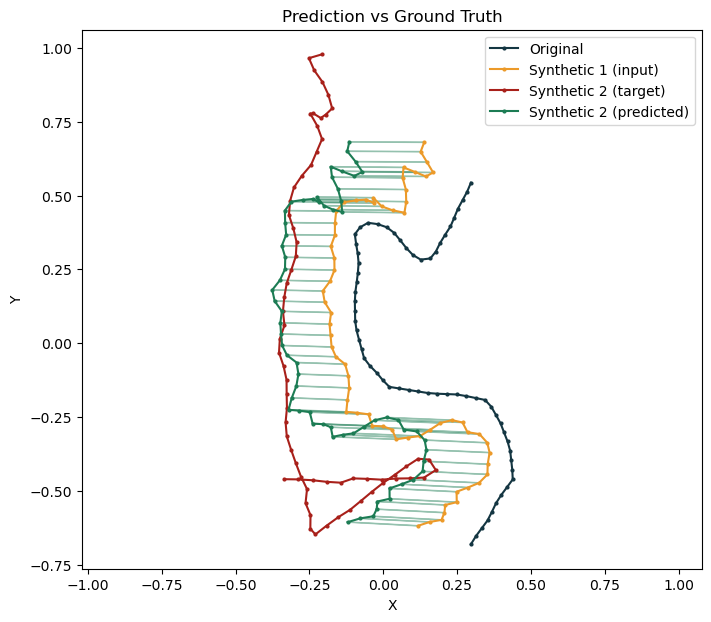

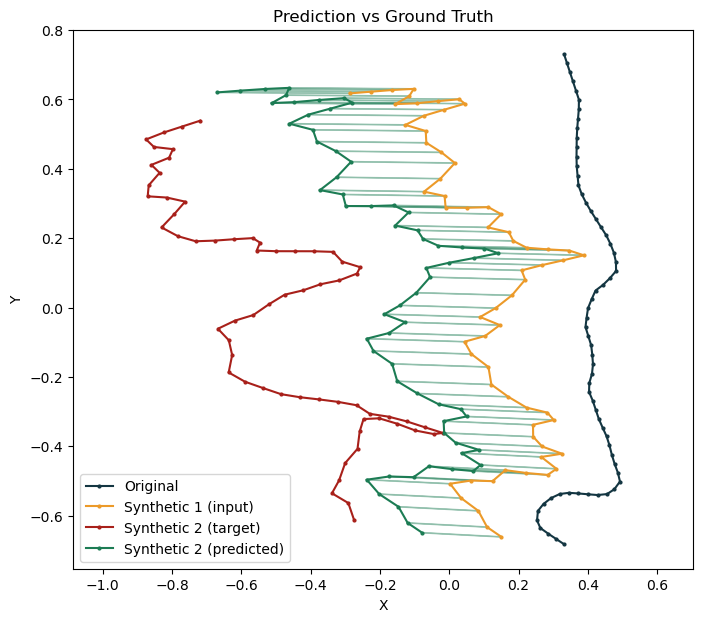

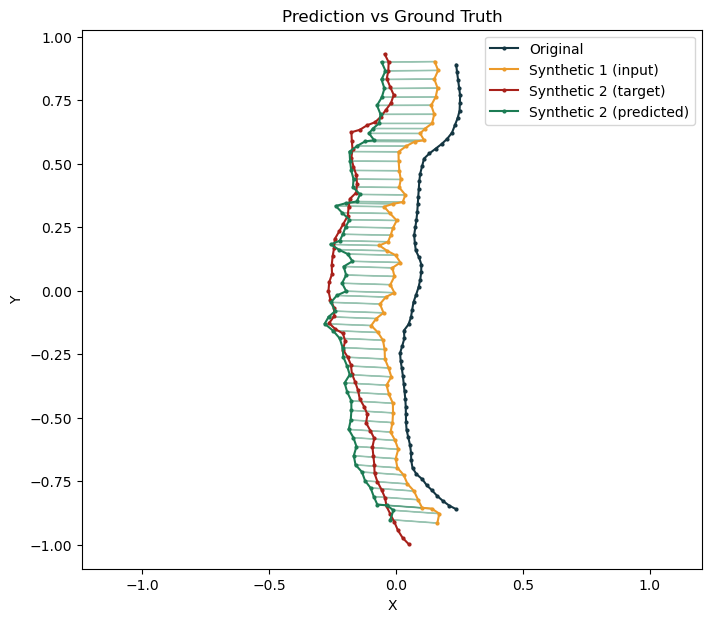

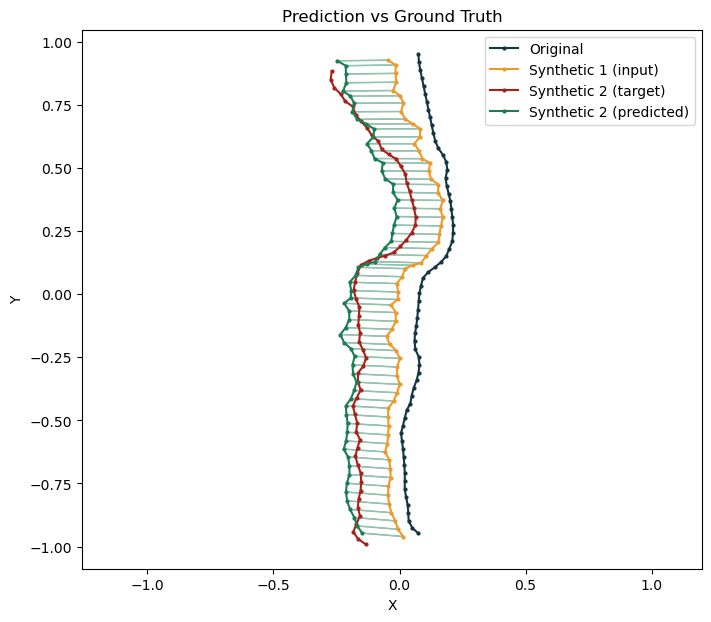

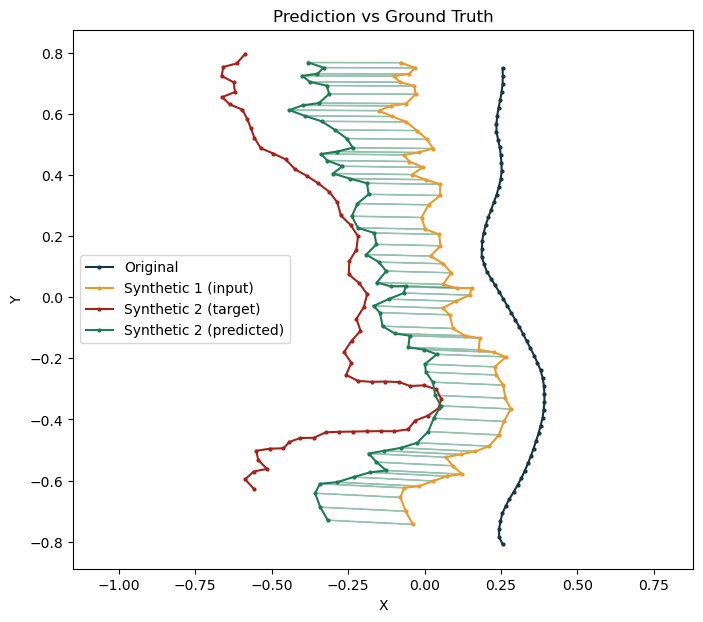

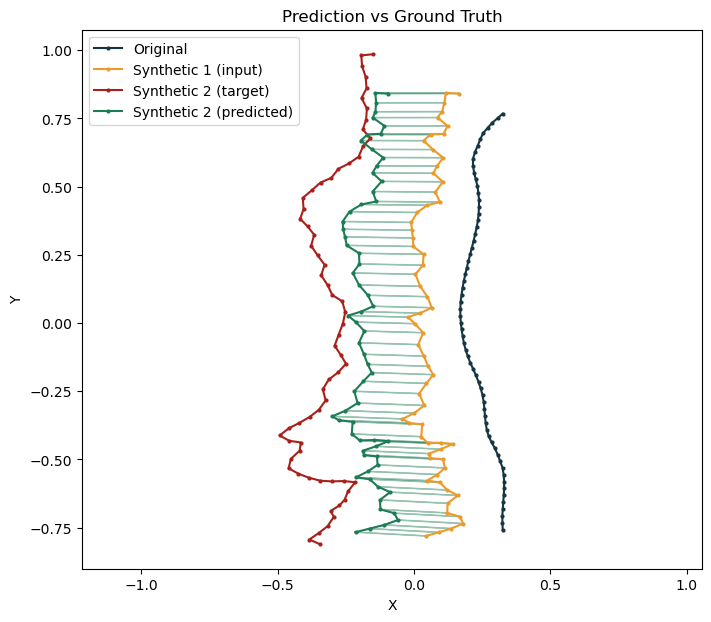

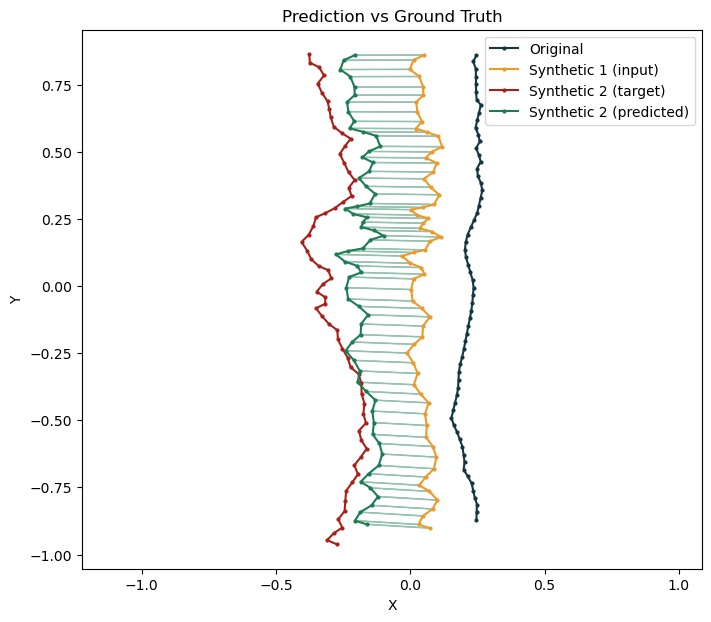

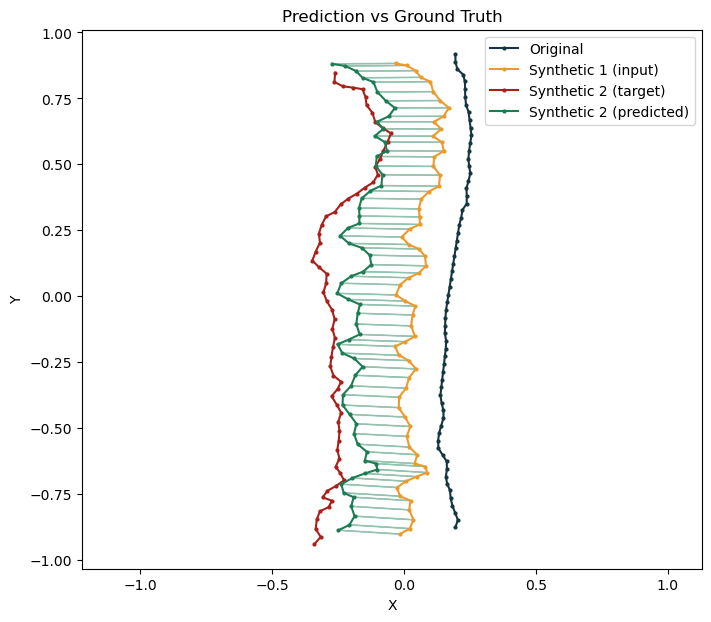

In [100]:
for i in range(100,150):
    sample_id = i
    plot_prediction(model, test_dataset[sample_id])
